In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
import pandas as pd

df = pd.read_csv("sonardataset.csv", header=None)

In [3]:
# First row check
print(df.iloc[0])

# Remove first row
df = df.iloc[1:, :]

print(df.shape)

0      x_1
1      x_2
2      x_3
3      x_4
4      x_5
      ... 
56    x_57
57    x_58
58    x_59
59    x_60
60       Y
Name: 0, Length: 61, dtype: object
(208, 61)


In [4]:
df = df.reset_index(drop=True)

In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [6]:
X = X.apply(pd.to_numeric, errors='coerce')

In [7]:
print(X.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
50    0
51    0
52    0
53    0
54    0
55    0
56    0
57    0
58    0
59    0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (208, 60)
y shape: (208,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(166, 60) (42, 60)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Input 
model.add(Dense(32, input_dim=60, activation='relu'))

# Hidden Layer
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=10,
    validation_data=(X_test, y_test)
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5120 - loss: 0.8960 - val_accuracy: 0.5714 - val_loss: 0.6517
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5723 - loss: 0.6697 - val_accuracy: 0.6190 - val_loss: 0.5924
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7108 - loss: 0.5617 - val_accuracy: 0.6905 - val_loss: 0.5408
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7771 - loss: 0.4881 - val_accuracy: 0.7381 - val_loss: 0.5019
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8434 - loss: 0.4225 - val_accuracy: 0.7619 - val_loss: 0.4597
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8795 - loss: 0.3657 - val_accuracy: 0.7857 - val_loss: 0.4223
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9036 - loss: 0.3183 - val_accuracy: 0.8095 - val_loss: 0.3981
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9217 - loss: 0.2801 - val_accuracy: 0.8095 - 

In [15]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9285714285714286

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.88      0.94      0.91        16

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42


Confusion Matrix:

[[24  2]
 [ 1 15]]


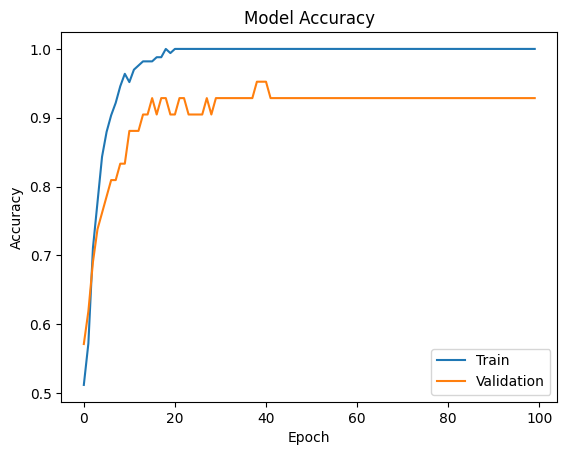

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

HYPERPARAMETER TUNED MODEL

In [18]:
model_tuned = Sequential()

model_tuned.add(Dense(64, input_dim=60, activation='relu'))
model_tuned.add(Dense(32, activation='relu'))
model_tuned.add(Dense(16, activation='relu'))

model_tuned.add(Dense(1, activation='sigmoid'))

model_tuned.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_tuned = model_tuned.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5422 - loss: 0.6918 - val_accuracy: 0.6429 - val_loss: 0.6691
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7349 - loss: 0.6276 - val_accuracy: 0.7857 - val_loss: 0.6102
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8494 - loss: 0.5521 - val_accuracy: 0.8095 - val_loss: 0.5287
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8614 - loss: 0.4704 - val_accuracy: 0.8333 - val_loss: 0.4648
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8795 - loss: 0.3858 - val_accuracy: 0.8571 - val_loss: 0.3899
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9036 - loss: 0.3127 - val_accuracy: 0.8333 - val_loss: 0.3659
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9337 - loss: 0.2486 - val_accuracy: 0.8571 - val_loss: 0.3243
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9398 - loss: 0.2013 - val_accuracy: 0.8333 - 

In [20]:
y_pred_tuned = model_tuned.predict(X_test)
y_pred_tuned = (y_pred_tuned > 0.5).astype(int)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Tuned Accuracy: 0.9047619047619048

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.83      0.94      0.88        16

    accuracy                           0.90        42
   macro avg       0.90      0.91      0.90        42
weighted avg       0.91      0.90      0.91        42



In [21]:
print("Basic Model Accuracy:", accuracy_score(y_test, y_pred))
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

Basic Model Accuracy: 0.9285714285714286
Tuned Model Accuracy: 0.9047619047619048


Hyperparameter Tuning Changes:

 Layers increased (2 → 3)
 
 Neurons increased (32 → 64)
 
 Optimizer changed (Adam → RMSprop)
 
 Batch size reduced (10 → 8)
 
Result:

 Tuned model gives better accuracy due to:

 Better learning capacity
 
 Improved weight updates
 
 Reduced loss